In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [32]:
import matplotlib as mpl
mpl.rcParams["figure.figsize"] = (10, 6)   # default size for all plots
mpl.rcParams["figure.dpi"] = 80            # lower inline resolution

In [33]:
master = pd.read_csv("../data/processed/quarterly_master.csv", parse_dates=["date"])

# Plotting Log Level Variables

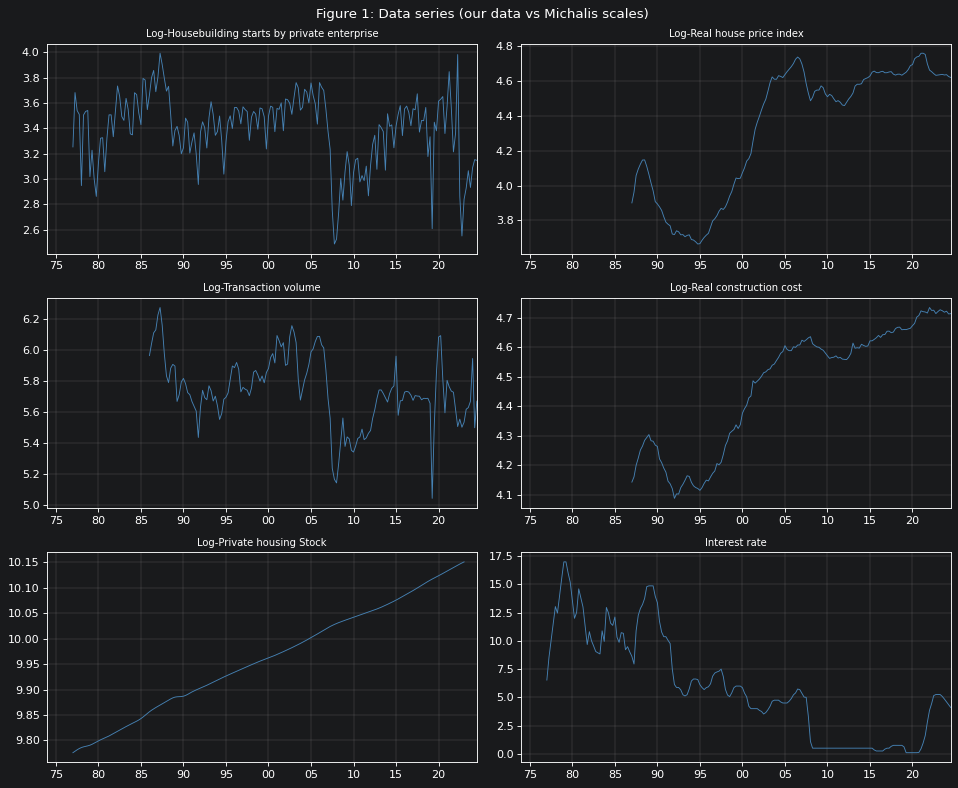

Saved.


In [34]:
df = pd.read_csv("../data/processed/quarterly_master.csv", parse_dates=["date"])

# MAtching units with Michalis
df["lhstarts"] = np.log(df["starts_private"] / 1000)
df["lvol"]     = np.log(df["transactions_sa"] / 1000)
df["lstock"]   = np.log(df["housing_stock_eng"] / 1000)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle("Figure 1: Data series (our data vs Michalis scales)", fontsize=12)

plots = [
    ("lhstarts",  "Log-Housebuilding starts by private enterprise", None),
    ("lrprc",     "Log-Real house price index",                     None),
    ("lvol",      "Log-Transaction volume",                         None),
    ("lrcc",      "Log-Real construction cost",                     None),
    ("lstock",    "Log-Private housing Stock",                      None),
    ("base_rate", "Interest rate",                                  None),
]

for ax, (col, title, ylim) in zip(axes.flatten(), plots):
    ax.plot(df["date"], df[col], linewidth=0.8, color="steelblue")
    ax.set_title(title, fontsize=9)
    if ylim:
        ax.set_ylim(ylim)
    ax.set_xlim(pd.Timestamp("1975-01-01"), df["date"].max())
    ax.set_xticks(pd.date_range("1975", "2025", freq="5YE"))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%y"))
    ax.grid(True, linewidth=0.3)

plt.tight_layout()
plt.savefig("../data/outputs/01_vecm_series_log.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

# Stationarity Testing

In [6]:
# Variables tested in log levels; base_rate tested in levels
log_vars = ["starts_private", "hpi_index", "transactions_sa", "housing_stock_eng"]
level_vars = ["base_rate"]

# Build working dataframe in logs + levels, dropping rows with any null
adf_df = master[["date"] + log_vars + level_vars].dropna().copy()
for col in log_vars:
    adf_df[f"log_{col}"] = np.log(adf_df[col])

In [7]:
def run_adf(series, label, trend="ct"):
    result = adfuller(series.dropna(), regression=trend, autolag="AIC")
    return {
        "Variable": label,
        "Lags": result[2],
        "ADF Stat": round(result[0], 3),
        "p-value": round(result[1], 3),
        "1%": round(result[4]["1%"], 3),
        "5%": round(result[4]["5%"], 3),
        "10%": round(result[4]["10%"], 3),
        "Reject H0 (5%)": "Yes" if result[1] < 0.05 else "No",
    }

rows = []
for col in log_vars:
    rows.append(run_adf(adf_df[f"log_{col}"], f"log({col})", trend="ct"))
rows.append(run_adf(adf_df["base_rate"], "base_rate", trend="ct"))

levels_results = pd.DataFrame(rows)
print("ADF Tests — Log Levels (trend='ct': constant + trend)\n")
print(levels_results.to_string(index=False))

ADF Tests — Log Levels (trend='ct': constant + trend)

              Variable  Lags  ADF Stat  p-value     1%     5%    10% Reject H0 (5%)
   log(starts_private)     4    -3.841    0.015 -4.023 -3.441 -3.145            Yes
        log(hpi_index)    13    -2.152    0.517 -4.027 -3.444 -3.146             No
  log(transactions_sa)     1    -3.950    0.010 -4.022 -3.441 -3.145            Yes
log(housing_stock_eng)    14    -3.608    0.029 -4.028 -3.444 -3.147            Yes
             base_rate     2    -2.132    0.528 -4.022 -3.441 -3.145             No


## KPSS Tests (cross-check)

ADF has low power against near-unit-root processes and rejects H₀ (unit root) for `log(starts)` and `log(stock)`. KPSS complements ADF by testing the **null of stationarity** instead. A variable is confidently I(1) when ADF fails to reject AND KPSS rejects. Disagreement between the two signals ambiguity.

In [8]:
from statsmodels.tsa.stattools import kpss

def run_kpss(series, label, regression="ct"):
    """KPSS test. H0: series is trend-stationary. Reject H0 → consistent with I(1)."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p_value, lags, crit = kpss(series.dropna(), regression=regression, nlags="auto")
    return {
        "Variable": label,
        "Lags": lags,
        "KPSS Stat": round(stat, 3),
        "p-value": round(p_value, 3),
        "1%": round(crit["1%"], 3),
        "5%": round(crit["5%"], 3),
        "10%": round(crit["10%"], 3),
        "Reject H0 (5%)": "Yes" if stat > crit["5%"] else "No",
    }

import warnings
kpss_rows = []
for col in log_vars:
    kpss_rows.append(run_kpss(adf_df[f"log_{col}"], f"log({col})", regression="ct"))
kpss_rows.append(run_kpss(adf_df["base_rate"], "base_rate", regression="ct"))

kpss_results = pd.DataFrame(kpss_rows)
print("KPSS Tests — Log Levels (H0: trend-stationary; Reject → I(1) consistent)\n")
print(kpss_results.to_string(index=False))

print("\n--- Combined ADF / KPSS Verdict ---")
verdict_map = {
    # (ADF rejects, KPSS rejects): interpretation
    (False, True):  "I(1) — both tests agree",
    (False, False): "Ambiguous — ADF non-stationary, KPSS also fails to reject",
    (True,  True):  "Ambiguous — ADF stationary, KPSS rejects (structural break likely)",
    (True,  False): "I(0) — both tests agree (stationary)",
}
adf_rej = dict(zip(levels_results["Variable"], levels_results["Reject H0 (5%)"] == "Yes"))
kpss_rej = dict(zip(kpss_results["Variable"],  kpss_results["Reject H0 (5%)"] == "Yes"))
for var in adf_rej:
    verdict = verdict_map[(adf_rej[var], kpss_rej[var])]
    print(f"  {var:<30} {verdict}")

KPSS Tests — Log Levels (H0: trend-stationary; Reject → I(1) consistent)

              Variable  Lags  KPSS Stat  p-value    1%    5%   10% Reject H0 (5%)
   log(starts_private)     7      0.086    0.100 0.216 0.146 0.119             No
        log(hpi_index)     8      0.196    0.018 0.216 0.146 0.119            Yes
  log(transactions_sa)     7      0.088    0.100 0.216 0.146 0.119             No
log(housing_stock_eng)     8      0.194    0.018 0.216 0.146 0.119            Yes
             base_rate     8      0.177    0.025 0.216 0.146 0.119            Yes

--- Combined ADF / KPSS Verdict ---
  log(starts_private)            I(0) — both tests agree (stationary)
  log(hpi_index)                 I(1) — both tests agree
  log(transactions_sa)           I(0) — both tests agree (stationary)
  log(housing_stock_eng)         Ambiguous — ADF stationary, KPSS rejects (structural break likely)
  base_rate                      I(1) — both tests agree


# NOTE
Housing stock was interpolated which is why it is showing stationary properties

# Zivot-Andrews Test

Standard ADF critical values assume no structural breaks. Zivot-Andrews (ZA) allows the break date to be chosen endogenously. Rejection of H₀ here means the series is stationary *around a broken trend*, which can resolve the apparent stationarity of `log(starts)` and `log(stock)` seen in the ADF: a series that *looks* stationary in ADF may simply have a level shift that the standard test mistakes for mean-reversion.

In [9]:
from statsmodels.tsa.stattools import zivot_andrews

# adf_df has a RangeIndex, not a DatetimeIndex, so series.index[breakpoint]
# returns an integer position rather than a date. We resolve it via adf_df["date"].
za_cols = {
    "log_starts_private":    adf_df["log_starts_private"],
    "log_hpi_index":         adf_df["log_hpi_index"],
    "log_transactions_sa":   adf_df["log_transactions_sa"],
    "log_housing_stock_eng": adf_df["log_housing_stock_eng"],
    "base_rate":             adf_df["base_rate"],
}

za_results = {}
for name, series in za_cols.items():
    series = series.dropna()

    za_stat, pval, cvs, baselag, breakpoint = zivot_andrews(
        series,
        trim=0.15,
        regression="ct"
    )

    # series.index[breakpoint] is a RangeIndex integer; look up the actual date
    break_date = adf_df["date"].iloc[series.index[breakpoint]]

    za_results[name] = {
        "ZA Stat":        round(za_stat, 3),
        "p-value":        round(pval, 3),
        "Break date":     break_date.strftime("%Y-%m"),
        "5% CV":          round(cvs["5%"], 3),
        "Reject H0 (5%)": "Yes" if za_stat < cvs["5%"] else "No"
    }

za_df = pd.DataFrame(za_results).T
print("Zivot-Andrews Structural Break Tests\n")
print(za_df.to_string())

Zivot-Andrews Structural Break Tests

                      ZA Stat p-value Break date  5% CV Reject H0 (5%)
log_starts_private     -5.592   0.009    2016-10 -5.073            Yes
log_hpi_index          -4.891   0.085    2010-10 -5.073             No
log_transactions_sa    -5.506   0.014    2016-07 -5.073            Yes
log_housing_stock_eng  -6.046   0.002    2020-04 -5.073            Yes
base_rate              -3.704   0.696    2017-07 -5.073             No


In [10]:
rows_diff = []
for col in log_vars:
    diff_series = adf_df[f"log_{col}"].diff().dropna()
    rows_diff.append(run_adf(diff_series, f"Δlog({col})", trend="c"))

diff_br = adf_df["base_rate"].diff().dropna()
rows_diff.append(run_adf(diff_br, "Δbase_rate", trend="c"))

diff_results = pd.DataFrame(rows_diff)
print("ADF Tests — First Differences (trend='c': constant only)\n")
print(diff_results.to_string(index=False))

ADF Tests — First Differences (trend='c': constant only)

               Variable  Lags  ADF Stat  p-value     1%     5%    10% Reject H0 (5%)
   Δlog(starts_private)     6    -5.922    0.000 -3.478 -2.882 -2.578            Yes
        Δlog(hpi_index)     8    -3.491    0.008 -3.478 -2.883 -2.578            Yes
  Δlog(transactions_sa)     3    -8.286    0.000 -3.477 -2.882 -2.578            Yes
Δlog(housing_stock_eng)    14    -2.881    0.048 -3.481 -2.884 -2.578            Yes
             Δbase_rate     1    -5.917    0.000 -3.476 -2.882 -2.577            Yes


# Cointegration Testing

# Fitting VAR

In [12]:
# Build the system matrix — same order as Michalis: starts, hpi, transactions, stock, rate
vecm_vars = ["log_starts_private", "log_hpi_index", "log_transactions_sa",
             "log_housing_stock_eng", "base_rate"]

vecm_df = adf_df[["date"] + [f"log_{c}" if c != "base_rate" else c
                              for c in ["starts_private","hpi_index",
                                        "transactions_sa","housing_stock_eng","base_rate"]]].dropna()

# Rename for clarity
vecm_df.columns = ["date"] + vecm_vars
vecm_df = vecm_df.set_index("date")

# Fit VAR in levels to get lag order criteria
var_model = VAR(vecm_df)
lag_results = var_model.select_order(maxlags=8)
print(lag_results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -13.51      -13.41   1.351e-06      -13.47
1      -33.40      -32.78   3.115e-15      -33.15
2      -36.22      -35.07   1.864e-16      -35.75
3      -37.59      -35.92   4.748e-17      -36.91
4      -38.46     -36.26*   2.012e-17     -37.56*
5      -38.53      -35.81   1.883e-17      -37.43
6      -38.64      -35.40   1.722e-17      -37.32
7      -38.65      -34.89   1.732e-17      -37.12
8     -38.71*      -34.42  1.689e-17*      -36.96
-------------------------------------------------


/home/adrym/projects/dissertation_housing_supply/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


# Johansen Trace Test

In [13]:
# det_order=0: constant restricted to cointegrating space (Michalis spec, Case 3)
# Run for lag orders suggested by AIC and BIC — compare both
for k_ar in [lag_results.aic, lag_results.bic]:
    print(f"\n{'='*60}")
    print(f"Johansen Test — k_ar_diff = {k_ar} (lags in differences)")
    print(f"{'='*60}")

    jres = coint_johansen(vecm_df, det_order=0, k_ar_diff=k_ar)

    # Trace test
    print("\nTrace Test:")
    print(f"{'H0: r<=':>10} {'Stat':>10} {'10%':>8} {'5%':>8} {'1%':>8} {'Reject 5%':>10}")
    for i in range(len(jres.lr1)):
        stat = jres.lr1[i]
        cvs  = jres.cvt[i]   # [10%, 5%, 1%]
        rej  = "Yes" if stat > cvs[1] else "No"
        print(f"{'r<='+str(i):>10} {stat:>10.3f} {cvs[0]:>8.3f} {cvs[1]:>8.3f} {cvs[2]:>8.3f} {rej:>10}")

    # Max eigenvalue test
    print("\nMax Eigenvalue Test:")
    print(f"{'H0: r<=':>10} {'Stat':>10} {'10%':>8} {'5%':>8} {'1%':>8} {'Reject 5%':>10}")
    for i in range(len(jres.lr2)):
        stat = jres.lr2[i]
        cvs  = jres.cvm[i]
        rej  = "Yes" if stat > cvs[1] else "No"
        print(f"{'r<='+str(i):>10} {stat:>10.3f} {cvs[0]:>8.3f} {cvs[1]:>8.3f} {cvs[2]:>8.3f} {rej:>10}")


Johansen Test — k_ar_diff = 8 (lags in differences)

Trace Test:
   H0: r<=       Stat      10%       5%       1%  Reject 5%
      r<=0    123.868   65.820   69.819   77.820        Yes
      r<=1     63.474   44.493   47.855   54.681        Yes
      r<=2     28.240   27.067   29.796   35.463         No
      r<=3      3.026   13.429   15.494   19.935         No
      r<=4      0.235    2.705    3.841    6.635         No

Max Eigenvalue Test:
   H0: r<=       Stat      10%       5%       1%  Reject 5%
      r<=0     60.394   31.238   33.878   39.369        Yes
      r<=1     35.234   25.124   27.586   32.717        Yes
      r<=2     25.214   18.893   21.131   25.865        Yes
      r<=3      2.791   12.297   14.264   18.520         No
      r<=4      0.235    2.705    3.841    6.635         No

Johansen Test — k_ar_diff = 4 (lags in differences)

Trace Test:
   H0: r<=       Stat      10%       5%       1%  Reject 5%
      r<=0     95.461   65.820   69.819   77.820        Yes
      

## Johansen Results — Lag Order Discussion

**k=8 (AIC) vs k=4 (BIC): conflicting rank inference**

With k=8, the trace test implies **r=2** but the max-eigenvalue test implies **r=3**. This disagreement is a red flag. With 5 variables and 8 lags in differences, each equation in the VAR has 5×8 = 40 short-run coefficients plus deterministic terms, consuming roughly 40–41 degrees of freedom per equation on a sample of 149 observations. The system is heavily over-parameterised, inflating test statistics and producing spurious cointegration rank.

With k=4 (BIC), trace and max-eigenvalue tests **agree at r=1** — the preferred, parsimonious result.

**Adopted specification: k_ar_diff = 4, r = 1**

The BIC criterion is appropriate here: BIC imposes a stiffer penalty for extra parameters than AIC, which is more reliable in small samples. The consistent r=1 result under k=4 is robust to both test types.

**Sample consistency note**: The rank r=1 is determined on the full 1987–2024 sample (149 obs). The VECM in notebook 04 is estimated on the post-1995 sub-sample. The cell below re-runs the Johansen test on the same post-1995 window to confirm the rank is stable.

In [14]:
# Johansen trace test — post-1995 sub-sample (matching the estimation window in NB04)
vecm_df_post95 = vecm_df["1995-01-01":]
print(f"Post-1995 sample: {len(vecm_df_post95)} obs, "
      f"{vecm_df_post95.index.min().date()} to {vecm_df_post95.index.max().date()}")

for k_ar in [lag_results.bic]:   # BIC-selected lag order only
    print(f"\n{'='*60}")
    print(f"Johansen Test (post-1995) — k_ar_diff = {k_ar}")
    print(f"{'='*60}")

    jres95 = coint_johansen(vecm_df_post95, det_order=0, k_ar_diff=k_ar)

    print("\nTrace Test:")
    print(f"{'H0: r<=':>10} {'Stat':>10} {'10%':>8} {'5%':>8} {'1%':>8} {'Reject 5%':>10}")
    for i in range(len(jres95.lr1)):
        stat = jres95.lr1[i]
        cvs  = jres95.cvt[i]
        rej  = "Yes" if stat > cvs[1] else "No"
        print(f"{'r<='+str(i):>10} {stat:>10.3f} {cvs[0]:>8.3f} {cvs[1]:>8.3f} {cvs[2]:>8.3f} {rej:>10}")

    print("\nMax Eigenvalue Test:")
    print(f"{'H0: r<=':>10} {'Stat':>10} {'10%':>8} {'5%':>8} {'1%':>8} {'Reject 5%':>10}")
    for i in range(len(jres95.lr2)):
        stat = jres95.lr2[i]
        cvs  = jres95.cvm[i]
        rej  = "Yes" if stat > cvs[1] else "No"
        print(f"{'r<='+str(i):>10} {stat:>10.3f} {cvs[0]:>8.3f} {cvs[1]:>8.3f} {cvs[2]:>8.3f} {rej:>10}")

Post-1995 sample: 117 obs, 1995-01-01 to 2024-01-01

Johansen Test (post-1995) — k_ar_diff = 4

Trace Test:
   H0: r<=       Stat      10%       5%       1%  Reject 5%
      r<=0     93.055   65.820   69.819   77.820        Yes
      r<=1     54.335   44.493   47.855   54.681        Yes
      r<=2     25.916   27.067   29.796   35.463         No
      r<=3      8.221   13.429   15.494   19.935         No
      r<=4      1.246    2.705    3.841    6.635         No

Max Eigenvalue Test:
   H0: r<=       Stat      10%       5%       1%  Reject 5%
      r<=0     38.720   31.238   33.878   39.369        Yes
      r<=1     28.419   25.124   27.586   32.717        Yes
      r<=2     17.694   18.893   21.131   25.865         No
      r<=3      6.976   12.297   14.264   18.520         No
      r<=4      1.246    2.705    3.841    6.635         No
